In [172]:
!pip install openpyxl

In [173]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
df=pd.read_excel('Data_Train.xlsx')
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


In [174]:
# Save the original data to CSV for the Streamlit app
df_original = df.copy()
df_original.to_csv('flight_price.csv', index=False)
print("✓ flight_price.csv saved for Streamlit app")

✓ flight_price.csv saved for Streamlit app


In [175]:
df.dropna(inplace=True)

In [176]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

In [177]:
# change the date of journey column to datetime format
df['Date_of_Journey']=pd.to_datetime(df['Date_of_Journey'],format='%d/%m/%Y')

In [178]:
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,2019-04-09,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,2019-04-27,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,2019-04-27,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,2019-03-01,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


In [179]:
df['Date']=df['Date_of_Journey'].dt.day

In [180]:
df['Month']=df['Date_of_Journey'].dt.month
df['Year']=df['Date_of_Journey'].dt.year

In [181]:
df.drop('Date_of_Journey',axis=1,inplace=True)
df

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6,2019
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5,2019
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107,9,4,2019
10679,Air India,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145,27,4,2019
10680,Jet Airways,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229,27,4,2019
10681,Vistara,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648,1,3,2019


In [182]:
df['Dep_Time']=pd.to_datetime(df['Dep_Time'],format='%H:%M')
df['Dep_Hour']=df['Dep_Time'].dt.hour
df['Dep_Minute']=df['Dep_Time'].dt.minute
df.drop('Dep_Time',axis=1,inplace=True)

In [183]:
df

,Airline,Source,Destination,Route,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Dep_Hour,Dep_Minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019,22,20
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,13:15,7h 25m,2 stops,No info,7662,1,5,2019,5,50
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,04:25 10 Jun,19h,2 stops,No info,13882,9,6,2019,9,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,23:30,5h 25m,1 stop,No info,6218,12,5,2019,18,5
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,21:35,4h 45m,1 stop,No info,13302,1,3,2019,16,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,CCU → BLR,22:25,2h 30m,non-stop,No info,4107,9,4,2019,19,55
10679,Air India,Kolkata,Banglore,CCU → BLR,23:20,2h 35m,non-stop,No info,4145,27,4,2019,20,45
10680,Jet Airways,Banglore,Delhi,BLR → DEL,11:20,3h,non-stop,No info,7229,27,4,2019,8,20
10681,Vistara,Banglore,New Delhi,BLR → DEL,14:10,2h 40m,non-stop,No info,12648,1,3,2019,11,30


In [184]:
# mapping={'Non-stop':0,'1 Stop':1,'2 Stops':2,'3 Stops':3,'4 Stops':4}
# df['Total_Stops']=df['Total_Stops'].map(mapping)
# df.head()
df['Total_Stops'].unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', '4 stops'],
      dtype=object)

In [185]:
mapping={'non-stop':0,'1 stop':1,'2 stops':2,'3 stops':3,'4 stops':4}
df['Total_Stops']=df['Total_Stops'].map(mapping)
df.head()

,Airline,Source,Destination,Route,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Dep_Hour,Dep_Minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,01:10 22 Mar,2h 50m,0,No info,3897,24,3,2019,22,20
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,13:15,7h 25m,2,No info,7662,1,5,2019,5,50
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,04:25 10 Jun,19h,2,No info,13882,9,6,2019,9,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,23:30,5h 25m,1,No info,6218,12,5,2019,18,5
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,21:35,4h 45m,1,No info,13302,1,3,2019,16,50


In [186]:
# route values_count
df['Route'].value_counts()

Route
DEL → BOM → COK          2376
BLR → DEL                1552
CCU → BOM → BLR           979
CCU → BLR                 724
BOM → HYD                 621
                         ... 
CCU → VTZ → BLR             1
CCU → IXZ → MAA → BLR       1
BOM → COK → MAA → HYD       1
BOM → CCU → HYD             1
BOM → BBI → HYD             1
Name: count, Length: 128, dtype: int64

In [187]:
# split the route column into multiple columns
df['Route_1']=df['Route'].str.split('→').str[0]
df['Route_2']=df['Route'].str.split('→').str[1]
df['Route_3']=df['Route'].str.split('→').str[2]
df['Route_4']=df['Route'].str.split('→').str[3]
df['Route_5']=df['Route'].str.split('→').str[4]
#fill the null values in route columns with None
df['Route_2'].fillna('None',inplace=True)
df['Route_3'].fillna('None',inplace=True)   
df['Route_4'].fillna('None',inplace=True)
df['Route_5'].fillna('None',inplace=True)
df['Route_1'].fillna('None',inplace=True)
df.drop('Route',axis=1,inplace=True)
df.head()

C:\Users\Sree Charan\AppData\Local\Temp\ipykernel_3848\1948232401.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Route_2'].fillna('None',inplace=True)
C:\Users\Sree Charan\AppData\Local\Temp\ipykernel_3848\1948232401.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

,Airline,Source,Destination,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Dep_Hour,Dep_Minute,Route_1,Route_2,Route_3,Route_4,Route_5
0,IndiGo,Banglore,New Delhi,01:10 22 Mar,2h 50m,0,No info,3897,24,3,2019,22,20,BLR,DEL,None,None,None
1,Air India,Kolkata,Banglore,13:15,7h 25m,2,No info,7662,1,5,2019,5,50,CCU,IXR,BBI,BLR,None
2,Jet Airways,Delhi,Cochin,04:25 10 Jun,19h,2,No info,13882,9,6,2019,9,25,DEL,LKO,BOM,COK,None
3,IndiGo,Kolkata,Banglore,23:30,5h 25m,1,No info,6218,12,5,2019,18,5,CCU,NAG,BLR,None,None
4,IndiGo,Banglore,New Delhi,21:35,4h 45m,1,No info,13302,1,3,2019,16,50,BLR,NAG,DEL,None,None


In [188]:
df

,Airline,Source,Destination,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Dep_Hour,Dep_Minute,Route_1,Route_2,Route_3,Route_4,Route_5
0,IndiGo,Banglore,New Delhi,01:10 22 Mar,2h 50m,0,No info,3897,24,3,2019,22,20,BLR,DEL,None,None,None
1,Air India,Kolkata,Banglore,13:15,7h 25m,2,No info,7662,1,5,2019,5,50,CCU,IXR,BBI,BLR,None
2,Jet Airways,Delhi,Cochin,04:25 10 Jun,19h,2,No info,13882,9,6,2019,9,25,DEL,LKO,BOM,COK,None
3,IndiGo,Kolkata,Banglore,23:30,5h 25m,1,No info,6218,12,5,2019,18,5,CCU,NAG,BLR,None,None
4,IndiGo,Banglore,New Delhi,21:35,4h 45m,1,No info,13302,1,3,2019,16,50,BLR,NAG,DEL,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,22:25,2h 30m,0,No info,4107,9,4,2019,19,55,CCU,BLR,None,None,None
10679,Air India,Kolkata,Banglore,23:20,2h 35m,0,No info,4145,27,4,2019,20,45,CCU,BLR,None,None,None
10680,Jet Airways,Banglore,Delhi,11:20,3h,0,No info,7229,27,4,2019,8,20,BLR,DEL,None,None,None
10681,Vistara,Banglore,New Delhi,14:10,2h 40m,0,No info,12648,1,3,2019,11,30,BLR,DEL,None,None,None


In [189]:
# remove the month from arrival time column and split the arrival time column into multiple columns
df['Arrival_Time']=pd.to_datetime(df['Arrival_Time'])
df['Arrival_Hour']=df['Arrival_Time'].dt.hour
df['Arrival_Minute']=df['Arrival_Time'].dt.minute
df.drop('Arrival_Time',axis=1,inplace=True)
df

C:\Users\Sree Charan\AppData\Local\Temp\ipykernel_3848\1321499663.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Arrival_Time']=pd.to_datetime(df['Arrival_Time'])


,Airline,Source,Destination,Duration,Total_Stops,Additional_Info,Price,Date,Month,Year,Dep_Hour,Dep_Minute,Route_1,Route_2,Route_3,Route_4,Route_5,Arrival_Hour,Arrival_Minute
0,IndiGo,Banglore,New Delhi,2h 50m,0,No info,3897,24,3,2019,22,20,BLR,DEL,None,None,None,1,10
1,Air India,Kolkata,Banglore,7h 25m,2,No info,7662,1,5,2019,5,50,CCU,IXR,BBI,BLR,None,13,15
2,Jet Airways,Delhi,Cochin,19h,2,No info,13882,9,6,2019,9,25,DEL,LKO,BOM,COK,None,4,25
3,IndiGo,Kolkata,Banglore,5h 25m,1,No info,6218,12,5,2019,18,5,CCU,NAG,BLR,None,None,23,30
4,IndiGo,Banglore,New Delhi,4h 45m,1,No info,13302,1,3,2019,16,50,BLR,NAG,DEL,None,None,21,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,2h 30m,0,No info,4107,9,4,2019,19,55,CCU,BLR,None,None,None,22,25
10679,Air India,Kolkata,Banglore,2h 35m,0,No info,4145,27,4,2019,20,45,CCU,BLR,None,None,None,23,20
10680,Jet Airways,Banglore,Delhi,3h,0,No info,7229,27,4,2019,8,20,BLR,DEL,None,None,None,11,20
10681,Vistara,Banglore,New Delhi,2h 40m,0,No info,12648,1,3,2019,11,30,BLR,DEL,None,None,None,14,10


In [190]:
# extract the duration column into multiple columns
df['Duration_Hour']=df['Duration'].str.extract(r'(\d+)h', expand=False).fillna(0).astype(int)
df['Duration_Minute']=df['Duration'].str.extract(r'(\d+)m', expand=False).fillna(0).astype(int)
df.drop('Duration',axis=1,inplace=True)

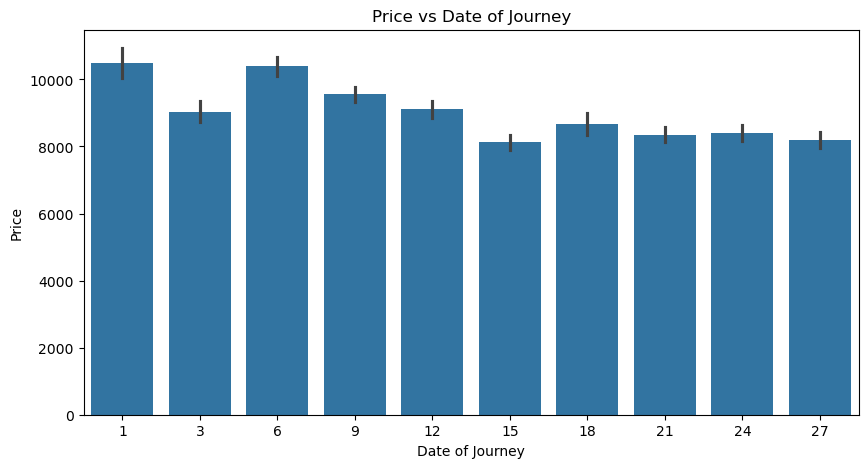

In [191]:
## visual line plot between price and date of journey
plt.figure(figsize=(10,5))
sns.barplot(x='Date',y='Price',data=df)
plt.title('Price vs Date of Journey')
plt.xlabel('Date of Journey')
plt.ylabel('Price')
plt.show()

In [192]:
df

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Date,Month,Year,Dep_Hour,Dep_Minute,Route_1,Route_2,Route_3,Route_4,Route_5,Arrival_Hour,Arrival_Minute,Duration_Hour,Duration_Minute
0,IndiGo,Banglore,New Delhi,0,No info,3897,24,3,2019,22,20,BLR,DEL,None,None,None,1,10,2,50
1,Air India,Kolkata,Banglore,2,No info,7662,1,5,2019,5,50,CCU,IXR,BBI,BLR,None,13,15,7,25
2,Jet Airways,Delhi,Cochin,2,No info,13882,9,6,2019,9,25,DEL,LKO,BOM,COK,None,4,25,19,0
3,IndiGo,Kolkata,Banglore,1,No info,6218,12,5,2019,18,5,CCU,NAG,BLR,None,None,23,30,5,25
4,IndiGo,Banglore,New Delhi,1,No info,13302,1,3,2019,16,50,BLR,NAG,DEL,None,None,21,35,4,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,0,No info,4107,9,4,2019,19,55,CCU,BLR,None,None,None,22,25,2,30
10679,Air India,Kolkata,Banglore,0,No info,4145,27,4,2019,20,45,CCU,BLR,None,None,None,23,20,2,35
10680,Jet Airways,Banglore,Delhi,0,No info,7229,27,4,2019,8,20,BLR,DEL,None,None,None,11,20,3,0
10681,Vistara,Banglore,New Delhi,0,No info,12648,1,3,2019,11,30,BLR,DEL,None,None,None,14,10,2,40


# Feature Engineering

In [193]:
# Label encoding replaced with one-hot encoding (see next cell)
# One-hot encoding is better because it doesn't impose ordinal relationships
pass

In [194]:
if 'Additional_Info' in df.columns:
    df.drop('Additional_Info', axis=1, inplace=True)
df.head()

,Airline,Source,Destination,Total_Stops,Price,Date,Month,Year,Dep_Hour,Dep_Minute,Route_1,Route_2,Route_3,Route_4,Route_5,Arrival_Hour,Arrival_Minute,Duration_Hour,Duration_Minute
0,IndiGo,Banglore,New Delhi,0,3897,24,3,2019,22,20,BLR,DEL,None,None,None,1,10,2,50
1,Air India,Kolkata,Banglore,2,7662,1,5,2019,5,50,CCU,IXR,BBI,BLR,None,13,15,7,25
2,Jet Airways,Delhi,Cochin,2,13882,9,6,2019,9,25,DEL,LKO,BOM,COK,None,4,25,19,0
3,IndiGo,Kolkata,Banglore,1,6218,12,5,2019,18,5,CCU,NAG,BLR,None,None,23,30,5,25
4,IndiGo,Banglore,New Delhi,1,13302,1,3,2019,16,50,BLR,NAG,DEL,None,None,21,35,4,45


In [195]:
# Save the raw data with categorical columns for Streamlit app
# This is BEFORE one-hot encoding so Airline, Source, Destination columns still exist
df.to_csv(r'C:\Users\Sree Charan\OneDrive\Desktop\Jupyter\Flights\flight_price.csv', index=False)
print("✓ flight_price.csv updated with categorical columns")

✓ flight_price.csv updated with categorical columns


In [196]:
# Use get_dummies for categorical columns instead of label encoding
df = pd.get_dummies(df, columns=['Airline', 'Source', 'Destination', 'Route_1', 'Route_2', 'Route_3', 'Route_4', 'Route_5'], drop_first=True)
df.head()


,Total_Stops,Price,Date,Month,Year,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute,Duration_Hour,...,Route_4_ HYD,Route_4_ HYD,Route_4_ NAG,Route_4_ TRV,Route_4_None,Route_5_ COK,Route_5_ DEL,Route_5_ HYD,Route_5_ VGA,Route_5_None
0,0,3897,24,3,2019,22,20,1,10,2,...,False,False,False,False,True,False,False,False,False,True
1,2,7662,1,5,2019,5,50,13,15,7,...,False,False,False,False,False,False,False,False,False,True
2,2,13882,9,6,2019,9,25,4,25,19,...,False,False,False,False,False,False,False,False,False,True
3,1,6218,12,5,2019,18,5,23,30,5,...,False,False,False,False,True,False,False,False,False,True
4,1,13302,1,3,2019,16,50,21,35,4,...,False,False,False,False,True,False,False,False,False,True


In [197]:
# remove extreme values from price column using IQR method
Q1=df['Price'].quantile(0.25)
Q3=df['Price'].quantile(0.75)   
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
df=df[(df['Price']>=lower_bound) & (df['Price']<=upper_bound)]
df

,Total_Stops,Price,Date,Month,Year,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute,Duration_Hour,...,Route_4_ HYD,Route_4_ HYD,Route_4_ NAG,Route_4_ TRV,Route_4_None,Route_5_ COK,Route_5_ DEL,Route_5_ HYD,Route_5_ VGA,Route_5_None
0,0,3897,24,3,2019,22,20,1,10,2,...,False,False,False,False,True,False,False,False,False,True
1,2,7662,1,5,2019,5,50,13,15,7,...,False,False,False,False,False,False,False,False,False,True
2,2,13882,9,6,2019,9,25,4,25,19,...,False,False,False,False,False,False,False,False,False,True
3,1,6218,12,5,2019,18,5,23,30,5,...,False,False,False,False,True,False,False,False,False,True
4,1,13302,1,3,2019,16,50,21,35,4,...,False,False,False,False,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,0,4107,9,4,2019,19,55,22,25,2,...,False,False,False,False,True,False,False,False,False,True
10679,0,4145,27,4,2019,20,45,23,20,2,...,False,False,False,False,True,False,False,False,False,True
10680,0,7229,27,4,2019,8,20,11,20,3,...,False,False,False,False,True,False,False,False,False,True
10681,0,12648,1,3,2019,11,30,14,10,2,...,False,False,False,False,True,False,False,False,False,True


In [198]:
# split the data into training and testing data
from sklearn.model_selection import train_test_split
X=df.drop('Price',axis=1)
y=df['Price']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_test

,Total_Stops,Date,Month,Year,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute,Duration_Hour,Duration_Minute,...,Route_4_ HYD,Route_4_ HYD,Route_4_ NAG,Route_4_ TRV,Route_4_None,Route_5_ COK,Route_5_ DEL,Route_5_ HYD,Route_5_ VGA,Route_5_None
9675,2,6,3,2019,6,40,21,20,14,40,...,False,False,False,False,False,False,False,False,False,True
4750,2,27,6,2019,8,10,12,35,28,25,...,False,False,False,False,False,False,False,False,False,True
503,1,6,6,2019,13,0,19,15,6,15,...,False,False,False,False,True,False,False,False,False,True
4489,1,12,6,2019,18,55,18,15,23,20,...,False,False,False,False,True,False,False,False,False,True
5604,1,9,3,2019,6,40,16,10,9,30,...,False,False,False,False,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213,1,3,6,2019,8,30,19,15,10,45,...,False,False,False,False,True,False,False,False,False,True
8444,1,18,5,2019,13,0,19,0,6,0,...,False,False,False,False,True,False,False,False,False,True
8758,2,6,5,2019,12,0,18,30,30,30,...,False,False,False,False,False,False,False,False,False,True
324,1,1,5,2019,8,25,20,45,12,20,...,False,False,False,False,True,False,False,False,False,True


In [199]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [200]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train_scaled,y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [201]:
y_pred=lr.predict(X_test_scaled)
y_pred

array([ 8655.85110965, 14079.9736081 , 10100.87267556, ...,
       11040.73912295, 12218.79582659,  3212.33386567], shape=(2118,))

In [202]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
print('R2 Score:',r2_score(y_test,y_pred))
print('Mean Absolute Error:',mean_absolute_error(y_test,y_pred))
print('Mean Squared Error:',mean_squared_error(y_test,y_pred))

R2 Score: 0.6860316334210725
Mean Absolute Error: 1681.0429112845754
Mean Squared Error: 5144026.676788826


In [203]:
# keep the model in a pickle file so that we can use for deployment
import pickle
pickle.dump(lr,open('flight_price_model.pkl','wb'))

In [204]:
import pickle
import os

# Get the directory where this notebook is located
notebook_dir = r'C:\Users\Sree Charan\OneDrive\Desktop\Jupyter\Flights'

# Save the scaler
pickle.dump(scaler, open(os.path.join(notebook_dir, 'scaler.pkl'), 'wb'))

# Save the feature columns (use X_train.columns, not X_train_scaled)
pickle.dump(X_train.columns.tolist(), open(os.path.join(notebook_dir, 'feature_columns.pkl'), 'wb'))

# Save the model (use your best model - rf or xgb, whichever gives better R2)
pickle.dump(lr, open(os.path.join(notebook_dir, 'flight_price_model.pkl'), 'wb'))

print("✓ scaler.pkl saved")
print("✓ feature_columns.pkl saved")
print("✓ flight_price_model.pkl saved")
print(f"Files saved to: {notebook_dir}")

✓ scaler.pkl saved
✓ feature_columns.pkl saved
✓ flight_price_model.pkl saved
Files saved to: C:\Users\Sree Charan\OneDrive\Desktop\Jupyter\Flights
